# Convergence Speed of Four $\pi$ Series


1. **Madhava–Leibniz**
   \begin{align}
   dfrac{\pi}{4} = \sum\_{k=0}^{\infty} \dfrac{(-1)^k}{2k+1}
   \end{align}

2. **Machin**  
   \begin{align}
   \dfrac{\pi}{4} = 4\arctan\!\dfrac{1}{5} - \arctan\!\dfrac{1}{239}
   \end{align}

3. **Ramanujan (1914)**
   \begin{align}
   dfrac{1}{\pi} = \dfrac{2\sqrt{2}}{9801}\sum\_{k=0}^{\infty}\dfrac{(4k)!\,(1103+26390k)}{(k!)^4\,396^{4k}}
   \end{align}

4. **Chudnovsky**
   \begin{align}
   dfrac{1}{\pi} = 12 \sum\_{k=0}^{\infty}\dfrac{(-1)^k(6k)!\,(545140134k+13591409)}{(3k)!\,(k!)^3\,640320^{3k+3/2}}
   \end{align}


All implemented with `numpy` + `numba.njit`. Per-term partial sums are stored so we can plot the absolute error $|\pi_n - \pi|$ versus term index $n$ on a log scale.

> **Caveat — float64 precision wall.** Ramanujan adds ~8 digits/term and Chudnovsky ~14 digits/term, so both saturate at machine epsilon ($\approx 2\times 10^{-16}$) within 1–2 iterations. To meaningfully compare _beyond_ float64 you need arbitrary precision (`mpmath` / `gmpy2`); the plot below shows the picture float64 _can_ show.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit, prange

PI_REF = np.pi  # float64 reference
EPS = np.finfo(np.float64).eps  # ~2.22e-16

Matplotlib is building the font cache; this may take a moment.


## 1. Madhava–Leibniz

Sublinear: $|\pi_n - \pi| \sim \dfrac{1}{n}$. Need $\sim 10^{15}$ terms for double precision.


In [2]:
@njit(cache=True, fastmath=False)
def madhava_leibniz(n_terms: int) -> np.ndarray:
    partials = np.empty(n_terms, dtype=np.float64)
    s = 0.0
    for k in range(n_terms):
        sign = 1.0 if (k & 1) == 0 else -1.0
        s += sign / (2.0 * k + 1.0)
        partials[k] = 4.0 * s
    return partials


# Parallel prefix-scan over all CPU cores:
# (1) parallel chunk sums,
# (2) tiny serial offset prefix,
# (3) parallel re-scan writing every partial.
@njit(parallel=True, fastmath=False)
def madhava_leibniz_parallel(n_terms: int) -> np.ndarray:
    n_threads = numba.get_num_threads()
    chunk = (n_terms + n_threads - 1) // n_threads
    chunk_sums = np.zeros(n_threads, dtype=np.float64)

    for c in prange(n_threads):
        start = c * chunk
        end = min(start + chunk, n_terms)
        local = 0.0
        for k in range(start, end):
            sign = 1.0 if (k & 1) == 0 else -1.0
            local += sign / (2.0 * k + 1.0)
        chunk_sums[c] = local

    offsets = np.zeros(n_threads, dtype=np.float64)
    for c in range(1, n_threads):
        offsets[c] = offsets[c - 1] + chunk_sums[c - 1]

    partials = np.empty(n_terms, dtype=np.float64)
    for c in prange(n_threads):
        start = c * chunk
        end = min(start + chunk, n_terms)
        local = offsets[c]
        for k in range(start, end):
            sign = 1.0 if (k & 1) == 0 else -1.0
            local += sign / (2.0 * k + 1.0)
            partials[k] = 4.0 * local

    return partials


# Warm-up + sanity check
_ = madhava_leibniz(10)
_ = madhava_leibniz_parallel(10)
leibniz_partials = madhava_leibniz(100_000)
print(
    f"Leibniz after 100k terms: {leibniz_partials[-1]:.10f}  err={abs(leibniz_partials[-1] - PI_REF):.2e}"
)
print(f"numba threads available: {numba.get_num_threads()}")

Leibniz after 100k terms: 3.1415826536  err=1.00e-05
numba threads available: 18


### Parallel scan for 10 M terms

Each partial sum depends on the previous one, so naively the loop is sequential. The trick is a two-pass parallel prefix scan:

1. **Pass 1 (parallel)** — split `n_terms` into `T` chunks (one per core), every thread reduces its chunk to a single scalar.
2. **Offset prefix (serial, tiny)** — prefix-sum the `T` chunk totals. `T` is the thread count (≪ `n_terms`), so this is essentially free.
3. **Pass 2 (parallel)** — every thread re-scans its chunk starting from its offset and writes the partials.

We do twice the arithmetic but on `T` cores, and the work is mostly memory-bound at this size (80 MB of partials), so the practical speedup is bounded by memory bandwidth rather than core count.


In [3]:
import time

N_BIG = 10_000_000

t0 = time.perf_counter()
ps_serial = madhava_leibniz(N_BIG)
t_serial = time.perf_counter() - t0

t0 = time.perf_counter()
ps_parallel = madhava_leibniz_parallel(N_BIG)
t_parallel = time.perf_counter() - t0

print(
    f"serial   ({N_BIG:>10,} terms): {t_serial * 1000:7.1f} ms   pi≈{ps_serial[-1]:.10f}   err={abs(ps_serial[-1] - PI_REF):.2e}"
)
print(
    f"parallel ({N_BIG:>10,} terms): {t_parallel * 1000:7.1f} ms   pi≈{ps_parallel[-1]:.10f}   err={abs(ps_parallel[-1] - PI_REF):.2e}"
)
print(f"speedup vs serial numba: {t_serial / t_parallel:.2f}x")
print(
    f"max |Δpartial| between the two: {np.max(np.abs(ps_serial - ps_parallel)):.2e}  (rounding noise from a different summation order)"
)

serial   (10,000,000 terms):     9.5 ms   pi≈3.1415925536   err=1.00e-07
parallel (10,000,000 terms):     7.2 ms   pi≈3.1415925536   err=1.00e-07
speedup vs serial numba: 1.31x
max |Δpartial| between the two: 1.71e-13  (rounding noise from a different summation order)


## 2. Machin

Two arctan series with $x=1/5$ and $x=1/239$, summed in lockstep. Each term contributes one $x^2$ factor, so error shrinks geometrically by $1/25$ per term (limited by the slower $1/5$ series).


In [4]:
@njit(cache=True, fastmath=False)
def machin(n_terms: int) -> np.ndarray:
    partials = np.empty(n_terms, dtype=np.float64)
    x1 = 1.0 / 5.0
    x2 = 1.0 / 239.0
    x1_sq = x1 * x1
    x2_sq = x2 * x2
    p1 = x1  # x1^(2k+1) for k=0
    p2 = x2
    a = 0.0  # arctan(1/5)
    b = 0.0  # arctan(1/239)
    for k in range(n_terms):
        sign = 1.0 if (k & 1) == 0 else -1.0
        denom = 2.0 * k + 1.0
        a += sign * p1 / denom
        b += sign * p2 / denom
        partials[k] = 4.0 * (4.0 * a - b)
        p1 *= x1_sq
        p2 *= x2_sq
    return partials


_ = machin(5)
machin_partials = machin(30)
print(
    f"Machin after 30 terms: {machin_partials[-1]:.16f}  err={abs(machin_partials[-1] - PI_REF):.2e}"
)

Machin after 30 terms: 3.1415926535897940  err=8.88e-16


## 3. Ramanujan (1914)

Adds roughly **8 decimal digits per term**. Factorials are folded into a recurrence to avoid overflow:

$$a_{k+1} = a_k \cdot \dfrac{(4k+1)(4k+2)(4k+3)(4k+4)}{(k+1)^4 \cdot 396^4}, \qquad a_0 = 1.$$


In [5]:
@njit(cache=True, fastmath=False)
def ramanujan(n_terms: int) -> np.ndarray:
    partials = np.empty(n_terms, dtype=np.float64)
    factor = 2.0 * np.sqrt(2.0) / 9801.0
    inv_396_4 = 1.0 / (396.0**4)
    a = 1.0  # k=0 term coefficient (4k)!/((k!)^4 * 396^(4k))
    s = 0.0
    for k in range(n_terms):
        L = 1103.0 + 26390.0 * k
        s += a * L
        partials[k] = 1.0 / (factor * s)
        kf = float(k)
        num = (4.0 * kf + 1.0) * (4.0 * kf + 2.0) * (4.0 * kf + 3.0) * (4.0 * kf + 4.0)
        den = (kf + 1.0) ** 4
        a = a * num / den * inv_396_4
    return partials


_ = ramanujan(2)
ramanujan_partials = ramanujan(10)
for k, v in enumerate(ramanujan_partials):
    print(f"  k={k}: pi≈{v:.16f}  err={abs(v - PI_REF):.2e}")

  k=0: pi≈3.1415927300133055  err=7.64e-08
  k=1: pi≈3.1415926535897936  err=4.44e-16
  k=2: pi≈3.1415926535897931  err=0.00e+00
  k=3: pi≈3.1415926535897931  err=0.00e+00
  k=4: pi≈3.1415926535897931  err=0.00e+00
  k=5: pi≈3.1415926535897931  err=0.00e+00
  k=6: pi≈3.1415926535897931  err=0.00e+00
  k=7: pi≈3.1415926535897931  err=0.00e+00
  k=8: pi≈3.1415926535897931  err=0.00e+00
  k=9: pi≈3.1415926535897931  err=0.00e+00


## 4. Chudnovsky

Adds roughly **14 decimal digits per term** — the algorithm behind every public $\pi$ record since 1989. We use the closed form

$$\pi = \dfrac{426880\sqrt{10005}}{\displaystyle\sum_{k=0}^{\infty} (-1)^k\, M_k\, (13591409+545140134k)\,/\,640320^{3k}}$$

with the $M_k$ recurrence (after simplifying $(6k+i)$ against $(3k+j)$ and $(k+1)$):

$$M_{k+1} = M_k \cdot \dfrac{24(2k+1)(6k+1)(6k+5)}{(k+1)^3}, \qquad M_0 = 1.$$


In [6]:
@njit(cache=True, fastmath=False)
def chudnovsky(n_terms: int) -> np.ndarray:
    partials = np.empty(n_terms, dtype=np.float64)
    C = 426880.0 * np.sqrt(10005.0)
    inv_640320_3 = 1.0 / (640320.0**3)
    M = 1.0  # M_0
    X = 1.0  # 640320^{-3k}, starts at k=0
    s = 0.0
    for k in range(n_terms):
        L = 13591409.0 + 545140134.0 * k
        sign = 1.0 if (k & 1) == 0 else -1.0
        s += sign * M * L * X
        partials[k] = C / s
        kf = float(k)
        # M_{k+1} = M_k * 24 (2k+1)(6k+1)(6k+5) / (k+1)^3
        M = (
            M
            * 24.0
            * (2.0 * kf + 1.0)
            * (6.0 * kf + 1.0)
            * (6.0 * kf + 5.0)
            / ((kf + 1.0) ** 3)
        )
        X = X * inv_640320_3
    return partials


_ = chudnovsky(2)
chudnovsky_partials = chudnovsky(5)
for k, v in enumerate(chudnovsky_partials):
    print(f"  k={k}: pi≈{v:.16f}  err={abs(v - PI_REF):.2e}")

  k=0: pi≈3.1415926535897341  err=5.91e-14
  k=1: pi≈3.1415926535897931  err=0.00e+00
  k=2: pi≈3.1415926535897931  err=0.00e+00
  k=3: pi≈3.1415926535897931  err=0.00e+00
  k=4: pi≈3.1415926535897931  err=0.00e+00


## Compare convergence speed (arbitrary precision)

Float64 caps every error at machine epsilon ($\approx 2 \times 10^{-16}$), which hides the actual asymptotic rates of Ramanujan and Chudnovsky. To see the real convergence, we recompute the partial sums in `mpmath` with `mp.dps = 150` and use that high-precision $\pi$ as the reference. Now $|\pi_n - \pi|$ can be plotted all the way down to $\sim 10^{-120}$.


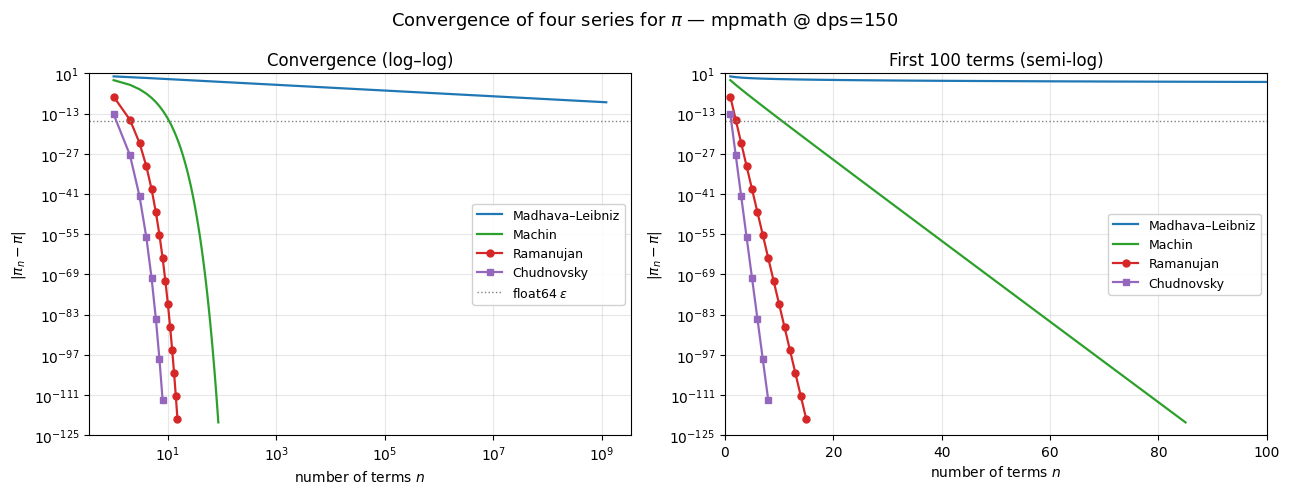

In [7]:
from mpmath import mp, mpf, sqrt as mp_sqrt

mp.dps = 150
PI_MP = mp.pi


# Arbitrary-precision versions (slow, but unbounded precision)
def madhava_leibniz_mp(n_terms):
    out = []
    s = mpf(0)
    for k in range(n_terms):
        sign = mpf(1) if (k & 1) == 0 else mpf(-1)
        s += sign / mpf(2 * k + 1)
        out.append(4 * s)
    return out


def machin_mp(n_terms):
    out = []
    x1, x2 = mpf(1) / 5, mpf(1) / 239
    x1_sq, x2_sq = x1 * x1, x2 * x2
    p1, p2 = x1, x2
    a, b = mpf(0), mpf(0)
    for k in range(n_terms):
        sign = mpf(1) if (k & 1) == 0 else mpf(-1)
        denom = mpf(2 * k + 1)
        a += sign * p1 / denom
        b += sign * p2 / denom
        out.append(4 * (4 * a - b))
        p1 *= x1_sq
        p2 *= x2_sq
    return out


def ramanujan_mp(n_terms):
    out = []
    factor = 2 * mp_sqrt(mpf(2)) / 9801
    inv_396_4 = mpf(1) / mpf(396) ** 4
    a, s = mpf(1), mpf(0)
    for k in range(n_terms):
        L = mpf(1103) + mpf(26390) * k
        s += a * L
        out.append(1 / (factor * s))
        num = mpf((4 * k + 1) * (4 * k + 2) * (4 * k + 3) * (4 * k + 4))
        den = mpf(k + 1) ** 4
        a = a * num / den * inv_396_4
    return out


def chudnovsky_mp(n_terms):
    out = []
    C = 426880 * mp_sqrt(mpf(10005))
    inv_640320_3 = mpf(1) / mpf(640320) ** 3
    M, X, s = mpf(1), mpf(1), mpf(0)
    for k in range(n_terms):
        L = mpf(13591409) + mpf(545140134) * k
        sign = mpf(1) if (k & 1) == 0 else mpf(-1)
        s += sign * M * L * X
        out.append(C / s)
        M = M * 24 * (2 * k + 1) * (6 * k + 1) * (6 * k + 5) / mpf(k + 1) ** 3
        X = X * inv_640320_3
    return out


def to_err(parts):
    # Fast path for float64 arrays (Madhava–Leibniz partials from the parallel numba scan).
    # Leibniz error at 10M terms is ~1e-7 ≫ float64 eps, so float64 captures the truth.
    if isinstance(parts, np.ndarray):
        e = np.abs(parts - float(PI_MP))
        e[e == 0] = 1e-300
        return e
    e = np.empty(len(parts))
    for i, p in enumerate(parts):
        d = abs(p - PI_MP)
        e[i] = float(d) if d > 0 else 1e-300
    return e


leibniz_mp_p = madhava_leibniz_parallel(
    1_200_000_000
)  # float64 partials, all CPU cores
machin_mp_p = machin_mp(85)  # reaches ~1e-115
ramanujan_mp_p = ramanujan_mp(15)  # reaches ~1e-120
chudnovsky_mp_p = chudnovsky_mp(8)  # reaches ~1e-113

err_leibniz = to_err(leibniz_mp_p)
err_machin = to_err(machin_mp_p)
err_ramanujan = to_err(ramanujan_mp_p)
err_chudnovsky = to_err(chudnovsky_mp_p)

series = [
    ("Madhava–Leibniz", err_leibniz, "#1f77b4", "-"),
    ("Machin", err_machin, "#2ca02c", "-"),
    ("Ramanujan", err_ramanujan, "#d62728", "-o"),
    ("Chudnovsky", err_chudnovsky, "#9467bd", "-s"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) log-log: terms vs error — full picture across all magnitudes
for name, e, c, ls in series:
    n = np.arange(1, len(e) + 1)
    ax1.loglog(n, e, ls, color=c, label=name, linewidth=1.6, markersize=5)
ax1.axhline(
    EPS, color="gray", linestyle=":", linewidth=1, label=r"float64 $\varepsilon$"
)
ax1.set_xlabel("number of terms $n$")
ax1.set_ylabel(r"$|\pi_n - \pi|$")
ax1.set_title("Convergence (log–log)")
ax1.set_ylim(1e-125, 10)
ax1.grid(True, which="both", alpha=0.3)
# Place legend in the empty upper-right region (Madhava is a thin line near top; rest is open)
ax1.legend(loc="center right", fontsize=9, framealpha=0.9)

# (b) zoom to first 100 terms — geometric per-term rates of the fast methods
for name, e, c, ls in series:
    n = np.arange(1, len(e) + 1)
    mask = n <= 100
    ax2.semilogy(n[mask], e[mask], ls, color=c, label=name, linewidth=1.6, markersize=5)
ax2.axhline(EPS, color="gray", linestyle=":", linewidth=1)
ax2.set_xlabel("number of terms $n$")
ax2.set_ylabel(r"$|\pi_n - \pi|$")
ax2.set_title("First 100 terms (semi-log)")
ax2.set_xlim(0, 100)
ax2.set_ylim(1e-125, 10)
ax2.grid(True, which="both", alpha=0.3)
# Lower-right is empty after Machin terminates around term 80
ax2.legend(loc="center right", fontsize=9, framealpha=0.9)

fig.suptitle(r"Convergence of four series for $\pi$ — mpmath @ dps=150", fontsize=13)
fig.tight_layout()
plt.show()

## Summary

Terms required to drop the error below each target. Now extends below the float64 floor (`>` means not reached within the iteration budget):


In [8]:
def terms_to_reach_mp(parts, target):
    if isinstance(parts, np.ndarray):
        below = np.abs(parts - float(PI_MP)) <= float(target)
        if not below.any():
            return None
        return int(below.argmax()) + 1
    for i, p in enumerate(parts):
        if abs(p - PI_MP) <= target:
            return i + 1
    return None


rows = [
    ("Madhava–Leibniz", leibniz_mp_p, len(leibniz_mp_p)),
    ("Machin", machin_mp_p, len(machin_mp_p)),
    ("Ramanujan", ramanujan_mp_p, len(ramanujan_mp_p)),
    ("Chudnovsky", chudnovsky_mp_p, len(chudnovsky_mp_p)),
]
targets = [mpf(10) ** -e for e in (3, 6, 15, 30, 60, 100)]

header = (
    f"{'method':<18}"
    + "".join(f"{f'<=1e-{int(-mp.log10(t))}':>11}" for t in targets)
    + f"{'budget':>10}"
)
print(header)
print("-" * len(header))
for name, p, budget in rows:
    cells = []
    for t in targets:
        n = terms_to_reach_mp(p, t)
        cells.append(
            f"{n:>11,}" if n is not None else f"{'>' + format(budget, ','):>11}"
        )
    print(f"{name:<18}" + "".join(cells) + f"{budget:>10,}")

method                 <=1e-3     <=1e-6    <=1e-15    <=1e-30    <=1e-60   <=1e-100    budget
----------------------------------------------------------------------------------------------
Madhava–Leibniz         1,000  1,000,001>1,200,000,000>1,200,000,000>1,200,000,000>1,200,000,0001,200,000,000
Machin                      2          4         11         21         42         71        85
Ramanujan                   1          1          2          4          8         13        15
Chudnovsky                  1          1          2          3          5          8         8
